# **Social Media Engagement Analysis**

##**Import and load the Dataset**

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/social_media_engagement1 (1).csv')

# Display the first few rows of the DataFrame
print(df.head())

   post_id   platform post_type        post_time  likes  comments  shares  \
0        1   Facebook     image  8/17/2023 14:45   2121       474     628   
1        2   Facebook  carousel   5/14/2023 0:45   3660       432     694   
2        3  Instagram      poll  2/21/2023 16:15   4955       408     688   
3        4    Twitter     image  11/16/2023 0:45   1183        90     187   
4        5    Twitter     video   5/23/2023 0:30   3499       247     286   

   post_day sentiment_score  
0  Thursday        positive  
1    Sunday         neutral  
2   Tuesday        negative  
3  Thursday        negative  
4   Tuesday        positive  


##**Understanding the Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


**Covert Post_time to Datetime**

In [ ]:
df['post_time'] = pd.to_datetime(df['post_time'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   post_id          100 non-null    int64         
 1   platform         100 non-null    object        
 2   post_type        100 non-null    object        
 3   post_time        100 non-null    datetime64[ns]
 4   likes            100 non-null    int64         
 5   comments         100 non-null    int64         
 6   shares           100 non-null    int64         
 7   post_day         100 non-null    object        
 8   sentiment_score  100 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 7.2+ KB
None


##**Checking for Duplicates**

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


##**Checking for Missing Values**

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64


##**Show summary statistics**

In [ ]:
print(df.describe())

          post_id            post_time        likes   comments      shares
count  100.000000                  100   100.000000  100.00000  100.000000
mean    50.500000  2023-06-26 12:04:57  2381.810000  202.66000  415.650000
min      1.000000  2023-01-01 06:00:00    15.000000   10.00000   16.000000
25%     25.750000  2023-04-09 16:48:45   895.750000   89.75000  183.000000
50%     50.500000  2023-06-13 18:22:30  2220.000000  171.00000  356.500000
75%     75.250000  2023-10-02 15:03:45  3593.250000  299.00000  689.500000
max    100.000000  2023-12-31 22:30:00  5000.000000  500.00000  993.000000
std     29.011492                  NaN  1632.573284  138.84067  283.877601


##**Engagement Patterns**

**Average Engagement by Post Type**

In [ ]:
# Calculate a total engagement score
df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by post_type and calculate the average total engagement
average_engagement_by_post_type = df.groupby('post_type')['total_engagement'].mean().sort_values(ascending=False)

# Display the results
print("Average Engagement by Post Type:")
print(average_engagement_by_post_type)

# Identify the post type with the highest average engagement
highest_engagement_type = average_engagement_by_post_type.index[0]
highest_engagement_value = average_engagement_by_post_type.iloc[0]

print(f"\nThe post type that generates the highest average engagement is '{highest_engagement_type}' with an average engagement of {highest_engagement_value:.2f}.")

Average Engagement by Post Type:
post_type
poll        3746.384615
video       3542.782609
carousel    3030.730769
image       2601.470588
text        2228.619048
Name: total_engagement, dtype: float64

The post type that generates the highest average engagement is 'poll' with an average engagement of 3746.38.


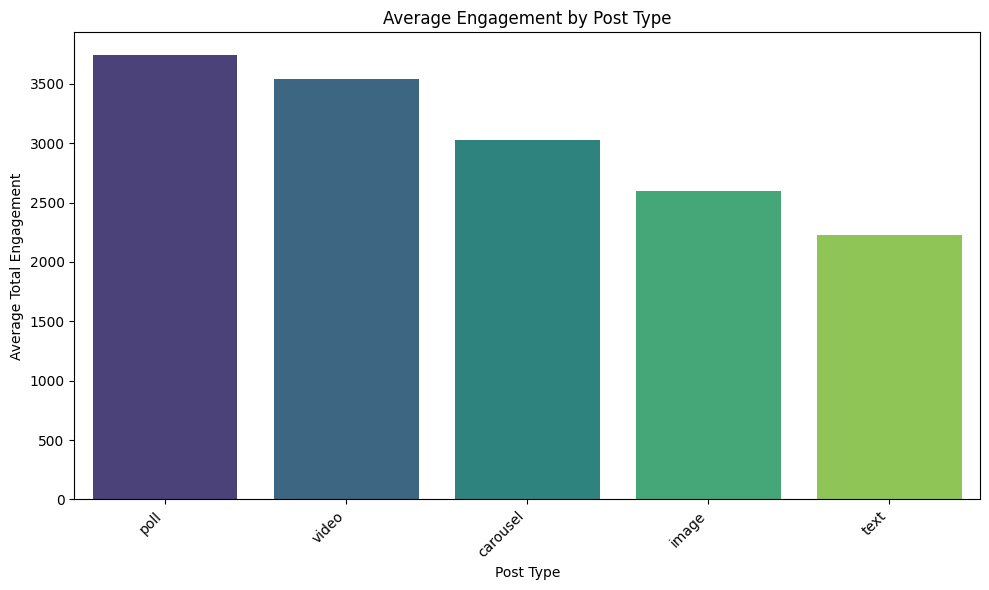

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for average engagement by post type
plt.figure(figsize=(10, 6))
sns.barplot(x=average_engagement_by_post_type.index, y=average_engagement_by_post_type.values, palette='viridis', hue=average_engagement_by_post_type.index, legend=False)
plt.title('Average Engagement by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Performance of Videos compared to other Post_Types**

In [ ]:
# The average engagement by post type is:
# poll        3746.38
# video       3542.78
# carousel    3030.73
# image       2601.47
# text        2228.62

# Based on this, 'poll' posts have the highest average total engagement, not 'video' posts.

**Average Engagement by Sentiment Score**

In [ ]:
# Calculate total engagement if not already calculated (from a previous step)
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by sentiment_score and calculate the average engagement metrics
sentiment_engagement = df.groupby('sentiment_score')[['likes', 'comments', 'shares', 'total_engagement']].mean()

# Display the results
print("Average Engagement Metrics by Sentiment Score:")
print(sentiment_engagement)

Average Engagement Metrics by Sentiment Score:
                       likes    comments      shares  total_engagement
sentiment_score                                                       
negative         2807.777778  229.962963  560.851852       3598.592593
neutral          1801.777778  197.407407  372.037037       2371.222222
positive         2472.239130  189.717391  356.021739       3017.978261


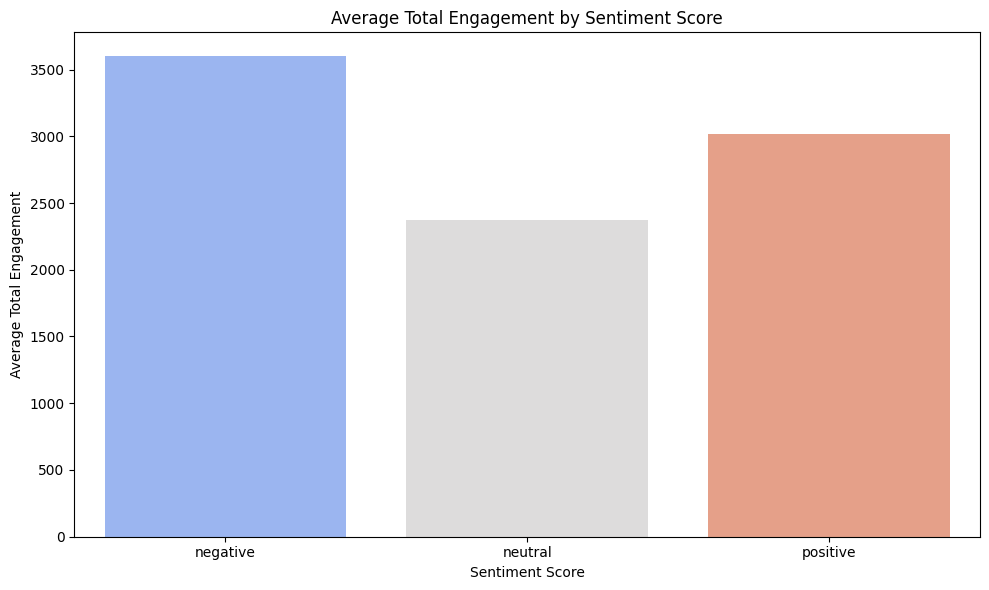

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for average total engagement by sentiment score
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_engagement.index, y=sentiment_engagement['total_engagement'], palette='coolwarm', hue=sentiment_engagement.index, legend=False)
plt.title('Average Total Engagement by Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Average Total Engagement')
plt.tight_layout()
plt.show()

From these results, we can observe:

Negative sentiment posts generally have the highest average engagement across all metrics (likes, comments, shares, and total engagement).
Positive sentiment posts come in second for total engagement, likes, and comments, but are slightly lower than neutral posts for shares.
Neutral sentiment posts show the lowest average engagement across all metrics, indicating they might be less effective in driving interaction compared to either positive or negative content.


## **Platform Comparisons**

##**Average Engagement by Platform**

In [ ]:
# Calculate total engagement if not already calculated
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by platform and calculate the average total engagement
average_engagement_by_platform = df.groupby('platform')['total_engagement'].mean().sort_values(ascending=False)

# Display the results
print("Average Engagement by Platform:")
print(average_engagement_by_platform)

# Identify the platform with the highest average engagement
highest_engagement_platform = average_engagement_by_platform.index[0]
highest_engagement_value = average_engagement_by_platform.iloc[0]

print(f"\nThe platform that generates the highest average engagement is '{highest_engagement_platform}' with an average engagement of {highest_engagement_value:.2f}.")

Average Engagement by Platform:
platform
Instagram    3757.444444
Facebook     3423.031250
Twitter      1725.218750
Name: total_engagement, dtype: float64

The platform that generates the highest average engagement is 'Instagram' with an average engagement of 3757.44.


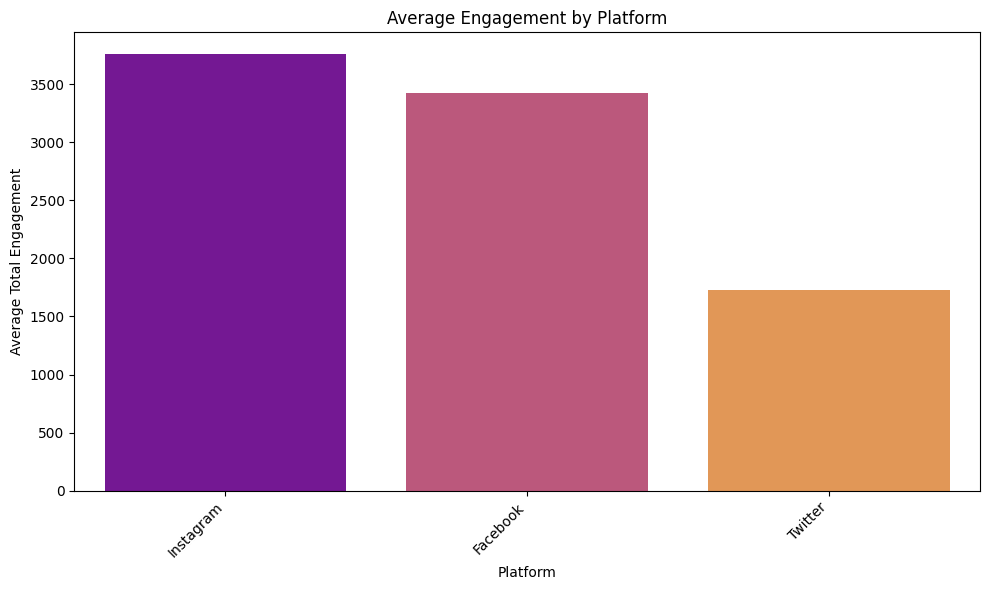

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for average engagement by platform
plt.figure(figsize=(10, 6))
sns.barplot(x=average_engagement_by_platform.index, y=average_engagement_by_platform.values, palette='plasma', hue=average_engagement_by_platform.index, legend=False)
plt.title('Average Engagement by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

##**Average engagement by post type and platform**





In [ ]:
# Calculate total engagement if not already calculated
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by platform and post_type, then calculate the average total engagement
average_engagement_by_platform_post_type = df.groupby(['platform', 'post_type'])['total_engagement'].mean().unstack(fill_value=0)

# Display the results
print("Average Engagement by Post Type per Platform:")
print(average_engagement_by_platform_post_type)

Average Engagement by Post Type per Platform:
post_type     carousel        image         poll         text        video
platform                                                                  
Facebook   3158.000000  1866.500000  4985.333333  3117.166667  4092.444444
Instagram  3316.777778  4160.000000  4325.166667  2330.000000  4862.285714
Twitter    2481.142857  1273.166667  1949.000000  1473.500000  1516.571429


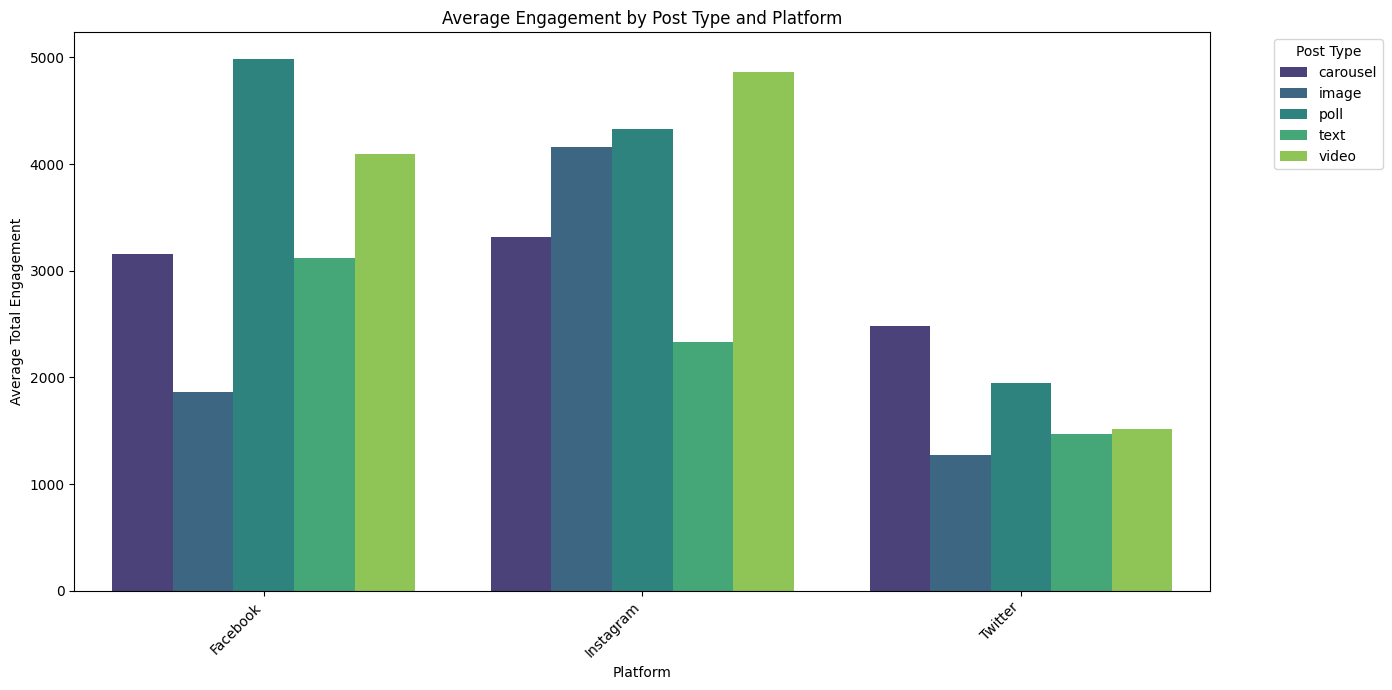

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
engagement_melted = average_engagement_by_platform_post_type.reset_index().melt(id_vars='platform', var_name='post_type', value_name='average_engagement')

# Create a grouped bar plot
plt.figure(figsize=(14, 7))
sns.barplot(data=engagement_melted, x='platform', y='average_engagement', hue='post_type', palette='viridis')
plt.title('Average Engagement by Post Type and Platform')
plt.xlabel('Platform')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Post Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The grouped bar chart showing average engagement by post type and platform has been successfully generated. This plot allows for a detailed comparison:

Instagram generally leads in engagement, especially with video and image posts.
Facebook shows very high engagement for poll posts and strong performance for video and carousel.
Twitter consistently has lower engagement across all post types compared to the other two platforms, with carousel and video being its relatively stronger formats.
This visualization highlights that the most effective post type can vary significantly depending on the platform.

In [ ]:
# Based on the previous analysis of 'Average Engagement by Post Type per Platform':
# - Polls and Videos are highly effective on Facebook.
# - Videos and Images are highly effective on Instagram.
# - Twitter generally has lower engagement across all types, with Carousel and Video being its relatively stronger formats.
# This confirms that certain post types are indeed more effective on specific platforms.

##**Sentiment Score Distribution by Platform**

In [ ]:
# Calculate the distribution of sentiment scores across platforms
sentiment_distribution_by_platform = pd.crosstab(df['platform'], df['sentiment_score'])

# Display the results
print("Sentiment Distribution by Platform:")
print(sentiment_distribution_by_platform)

# Optionally, display as percentages for easier comparison
print("\nSentiment Distribution (Percentages) by Platform:")
print(pd.crosstab(df['platform'], df['sentiment_score'], normalize='index').round(3) * 100)

Sentiment Distribution by Platform:
sentiment_score  negative  neutral  positive
platform                                    
Facebook               11        9        12
Instagram              14        8        14
Twitter                 2       10        20

Sentiment Distribution (Percentages) by Platform:
sentiment_score  negative  neutral  positive
platform                                    
Facebook             34.4     28.1      37.5
Instagram            38.9     22.2      38.9
Twitter               6.2     31.2      62.5


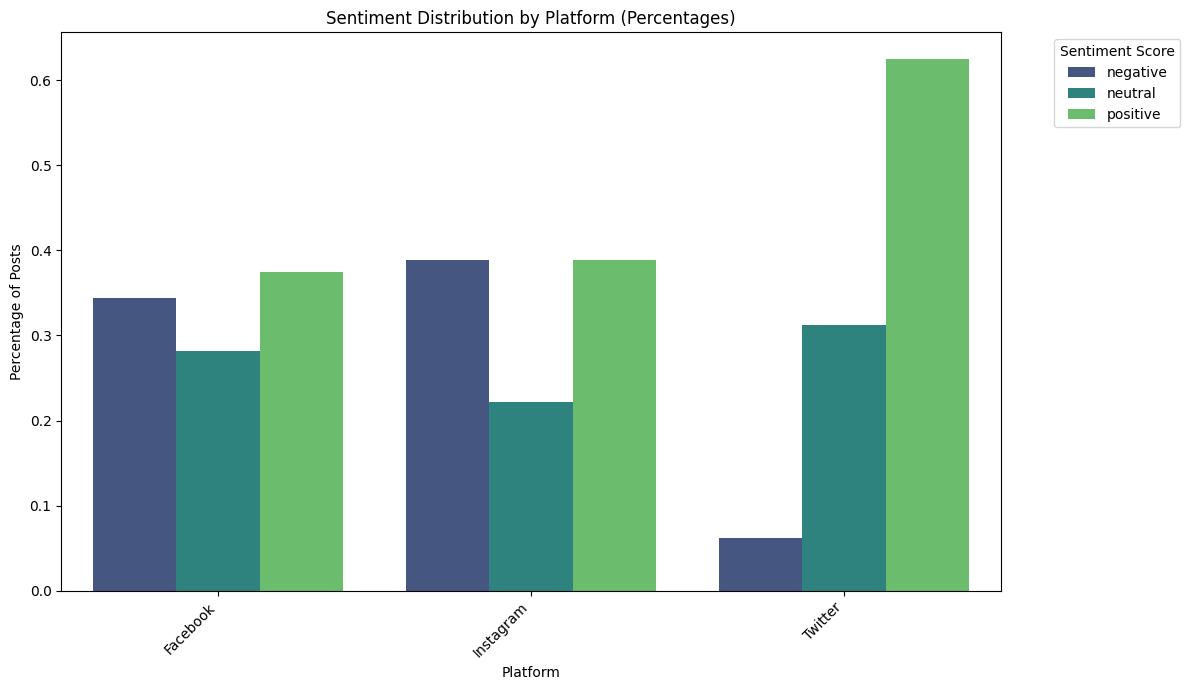

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sentiment distribution as percentages for better comparison
sentiment_distribution_percentages = pd.crosstab(df['platform'], df['sentiment_score'], normalize='index')

# Melt the DataFrame for seaborn plotting
sentiment_melted = sentiment_distribution_percentages.reset_index().melt(id_vars='platform', var_name='sentiment_score', value_name='percentage')

# Create a grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(data=sentiment_melted, x='platform', y='percentage', hue='sentiment_score', palette='viridis')
plt.title('Sentiment Distribution by Platform (Percentages)')
plt.xlabel('Platform')
plt.ylabel('Percentage of Posts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Temporal Analysis**

**The average engagement by day of the week**

In [ ]:
# Calculate total engagement if not already calculated
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by post_day and calculate the average total engagement
average_engagement_by_day = df.groupby('post_day')['total_engagement'].mean().sort_values(ascending=False)

# Display the results
print("Average Engagement by Day of the Week:")
print(average_engagement_by_day)

# Identify the day with the highest average engagement
highest_engagement_day = average_engagement_by_day.index[0]
highest_engagement_value = average_engagement_by_day.iloc[0]

print(f"\nThe day of the week that generates the highest average engagement is '{highest_engagement_day}' with an average engagement of {highest_engagement_value:.2f}.")

Average Engagement by Day of the Week:
post_day
Sunday       3478.142857
Friday       3316.687500
Wednesday    3264.944444
Tuesday      2989.533333
Thursday     2854.500000
Saturday     2467.400000
Monday       2208.454545
Name: total_engagement, dtype: float64

The day of the week that generates the highest average engagement is 'Sunday' with an average engagement of 3478.14.


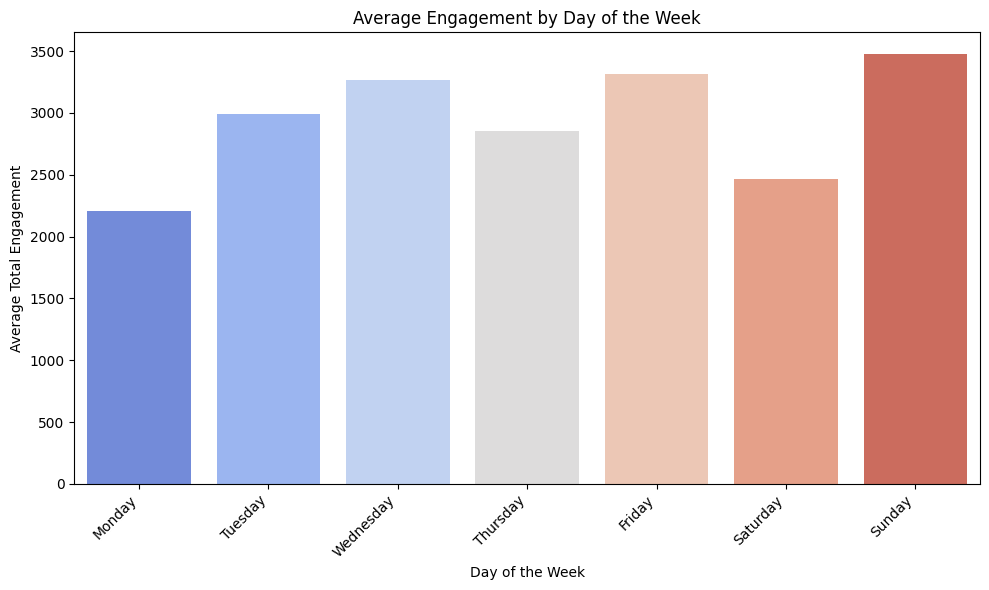

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order of days of the week for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reindex the series to ensure correct order in the plot
average_engagement_by_day_ordered = average_engagement_by_day.reindex(day_order)

# Create a bar plot for average engagement by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x=average_engagement_by_day_ordered.index, y=average_engagement_by_day_ordered.values, palette='coolwarm', hue=average_engagement_by_day_ordered.index, legend=False)
plt.title('Average Engagement by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

The bar chart clearly shows that Sunday is the day with the highest average engagement, followed closely by Friday and Wednesday. Monday and Saturday tend to have lower engagement compared to other weekdays.

**Average Likes and Shares by Time of Day Category**

In [ ]:
# Extract the hour from the 'post_time' column
df['post_hour'] = df['post_time'].dt.hour

# Define a function to categorize time of day
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

# Apply the function to create a new 'time_of_day_category' column
df['time_of_day_category'] = df['post_hour'].apply(get_time_of_day)

# Calculate average likes and shares by time of day category
time_of_day_engagement = df.groupby('time_of_day_category')[['likes', 'shares']].mean().sort_values(by='likes', ascending=False)

print("Average Likes and Shares by Time of Day Category:")
print(time_of_day_engagement)

Average Likes and Shares by Time of Day Category:
                            likes      shares
time_of_day_category                         
Night                 2906.538462  459.538462
Afternoon             2254.400000  447.400000
Morning               2224.760000  375.080000
Evening               2109.666667  377.291667


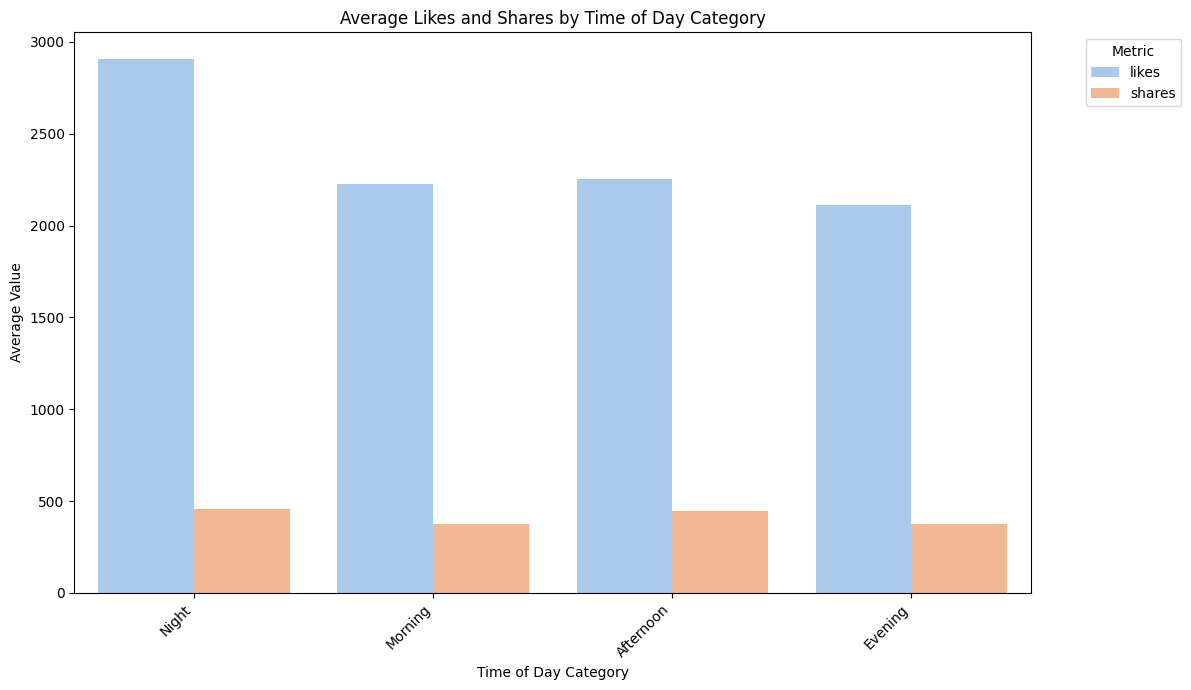

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting
time_of_day_melted = time_of_day_engagement.reset_index().melt(id_vars='time_of_day_category', var_name='metric', value_name='average_value')

# Define a specific order for time of day categories for better visualization
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']
time_of_day_melted['time_of_day_category'] = pd.Categorical(time_of_day_melted['time_of_day_category'], categories=time_order, ordered=True)

# Create a grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=time_of_day_melted, x='time_of_day_category', y='average_value', hue='metric', palette='pastel')
plt.title('Average Likes and Shares by Time of Day Category')
plt.xlabel('Time of Day Category')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Key Observations:

Night posts (12 AM - 5 AM) generally receive the highest average likes (2906.54) and shares (459.54).
Afternoon posts (12 PM - 5 PM) come in second for both likes and shares.
Morning (6 AM - 11 AM) and Evening (6 PM - 11 PM) posts tend to have lower average likes and shares compared to Night and Afternoon posts.
This suggests that posts made during the Night and Afternoon hours might be more effective in generating engagement in terms of likes and shares.

**Are there seasonal or monthly peaks in engagement patterns?**

In [ ]:
# Extract month and year from post_time
df['post_month'] = df['post_time'].dt.to_period('M')

# Calculate total engagement if not already calculated
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Group by month and calculate the average total engagement
average_engagement_by_month = df.groupby('post_month')['total_engagement'].mean().sort_values(ascending=False)

# Display the results
print("Average Engagement by Month:")
print(average_engagement_by_month)

# Identify the month with the highest average engagement
highest_engagement_month = average_engagement_by_month.index[0]
highest_engagement_value = average_engagement_by_month.iloc[0]

print(f"\nThe month that generates the highest average engagement is '{highest_engagement_month}' with an average engagement of {highest_engagement_value:.2f}.")

Average Engagement by Month:
post_month
2023-03    3666.833333
2023-01    3662.500000
2023-09    3554.000000
2023-04    3518.166667
2023-12    3253.300000
2023-07    3244.384615
2023-02    3013.750000
2023-11    2784.125000
2023-08    2764.250000
2023-05    2621.117647
2023-06    2598.400000
2023-10    1600.750000
Freq: M, Name: total_engagement, dtype: float64

The month that generates the highest average engagement is '2023-03' with an average engagement of 3666.83.


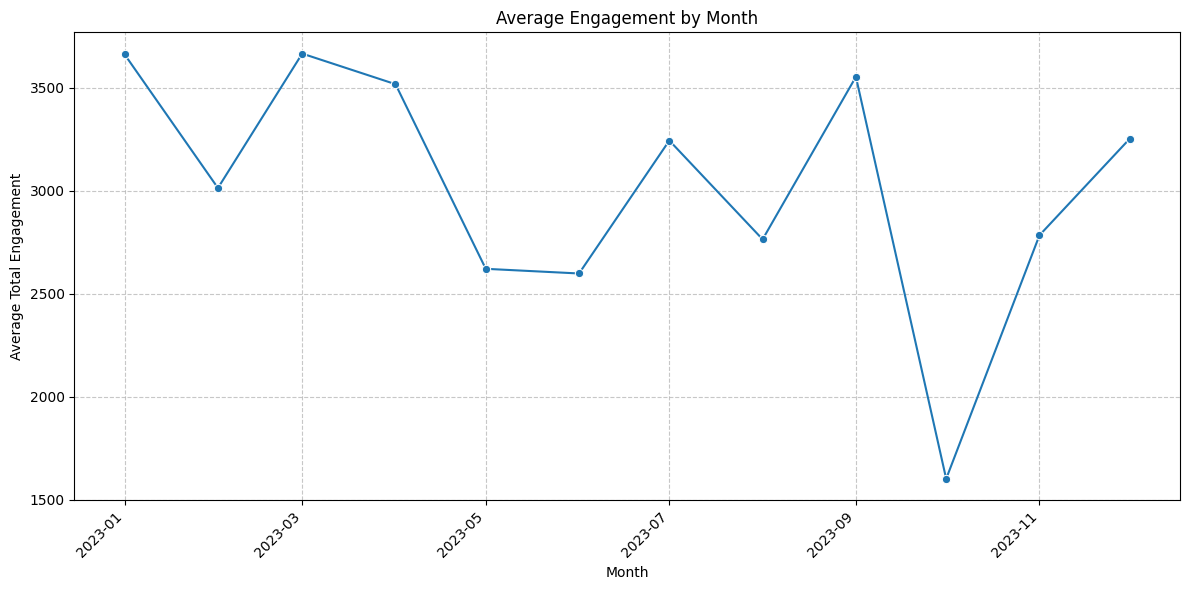

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert PeriodIndex to datetime for better plotting
average_engagement_by_month_df = average_engagement_by_month.to_frame(name='average_engagement').reset_index()
average_engagement_by_month_df['post_month'] = average_engagement_by_month_df['post_month'].dt.to_timestamp()

# Sort by month for chronological order
average_engagement_by_month_df = average_engagement_by_month_df.sort_values(by='post_month')

# Create a line plot for average engagement by month
plt.figure(figsize=(12, 6))
sns.lineplot(x=average_engagement_by_month_df['post_month'], y=average_engagement_by_month_df['average_engagement'], marker='o')
plt.title('Average Engagement by Month')
plt.xlabel('Month')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Peaks: Engagement appears to be highest in early months like January and March, and also in September.
Troughs: October shows a significant drop in average engagement, indicating it might be a less engaging month for posts.
This visualization helps confirm that engagement patterns do fluctuate monthly, with certain periods being more active than others.



## **Cross-Metric Relationships**

**Correlation between Likes and Shares**

In [ ]:
# Calculate the correlation between 'likes' and 'shares'
correlation_likes_shares = df['likes'].corr(df['shares'])

print(f"The correlation between likes and shares is: {correlation_likes_shares:.2f}")

The correlation between likes and shares is: 0.24


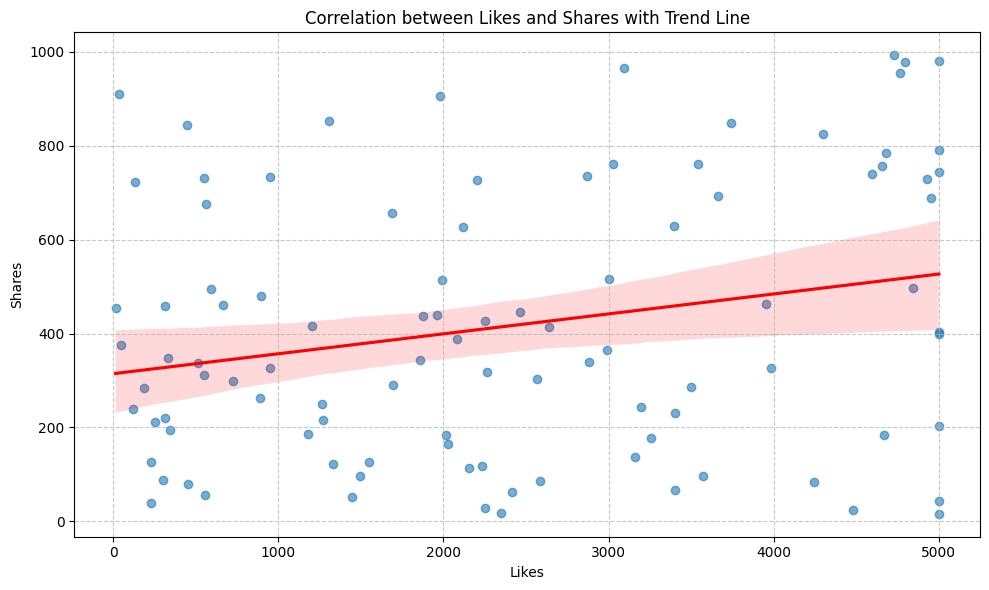

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='likes', y='shares', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlation between Likes and Shares with Trend Line')
plt.xlabel('Likes')
plt.ylabel('Shares')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The red line represents the linear regression, which further illustrates the weak positive correlation (0.24) between these two metrics. You can visually observe that as likes increase, shares generally tend to increase, but the data points are quite scattered around the line, confirming the weak nature of this relationship.



 **The relationship between comments and sentiment scores.**

In [ ]:
# Create a numerical mapping for sentiment scores
sentiment_mapping = {'negative': -1, 'neutral': 0, 'positive': 1}
df['numerical_sentiment'] = df['sentiment_score'].map(sentiment_mapping)

# Calculate the correlation between comments and the numerical sentiment score
correlation_comments_sentiment = df['comments'].corr(df['numerical_sentiment'])

print(f"The correlation between comments and numerical sentiment score is: {correlation_comments_sentiment:.2f}")

# Additionally, re-display the average comments by sentiment score for context
print("\nAverage Comments by Sentiment Score:")
print(df.groupby('sentiment_score')['comments'].mean().sort_values(ascending=False))

The correlation between comments and numerical sentiment score is: -0.12

Average Comments by Sentiment Score:
sentiment_score
negative    229.962963
neutral     197.407407
positive    189.717391
Name: comments, dtype: float64


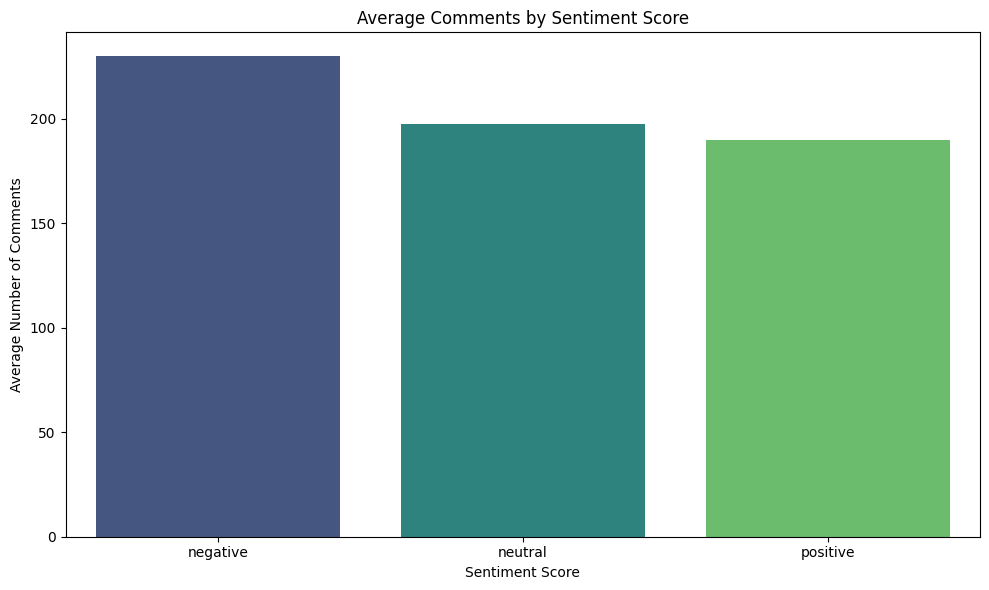

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numerical_sentiment is available (from previous steps)
if 'numerical_sentiment' not in df.columns:
    sentiment_mapping = {'negative': -1, 'neutral': 0, 'positive': 1}
    df['numerical_sentiment'] = df['sentiment_score'].map(sentiment_mapping)

# Calculate average comments by sentiment score
average_comments_by_sentiment = df.groupby('sentiment_score')['comments'].mean().sort_values(ascending=False)

# Define a specific order for sentiment categories for better visualization
sentiment_order = ['negative', 'neutral', 'positive']
average_comments_by_sentiment_ordered = average_comments_by_sentiment.reindex(sentiment_order)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=average_comments_by_sentiment_ordered.index, y=average_comments_by_sentiment_ordered.values, palette='viridis', hue=average_comments_by_sentiment_ordered.index, legend=False)
plt.title('Average Comments by Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Average Number of Comments')
plt.tight_layout()
plt.show()

This indicates a very weak negative correlation. In other words, as the sentiment score increases (moving from negative to positive), the average number of comments tends to slightly decrease, but the relationship is not strong.

To provide more context, here are the average comments by sentiment score:

**The strongest predictor of overall engagement success**

In [ ]:
# Ensure 'total_engagement' is calculated
if 'total_engagement' not in df.columns:
    df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# Calculate correlations of individual metrics with total engagement
correlation_likes_total_engagement = df['likes'].corr(df['total_engagement'])
correlation_comments_total_engagement = df['comments'].corr(df['total_engagement'])
correlation_shares_total_engagement = df['shares'].corr(df['total_engagement'])

print(f"Correlation between Likes and Total Engagement: {correlation_likes_total_engagement:.2f}")
print(f"Correlation between Comments and Total Engagement: {correlation_comments_total_engagement:.2f}")
print(f"Correlation between Shares and Total Engagement: {correlation_shares_total_engagement:.2f}")

# Determine the strongest predictor
correlations = {
    'likes': correlation_likes_total_engagement,
    'comments': correlation_comments_total_engagement,
    'shares': correlation_shares_total_engagement
}

strongest_predictor = max(correlations, key=correlations.get)
print(f"\nThe strongest predictor of overall engagement success is: {strongest_predictor} (Correlation: {correlations[strongest_predictor]:.2f})")

Correlation between Likes and Total Engagement: 0.98
Correlation between Comments and Total Engagement: 0.39
Correlation between Shares and Total Engagement: 0.40

The strongest predictor of overall engagement success is: likes (Correlation: 0.98)


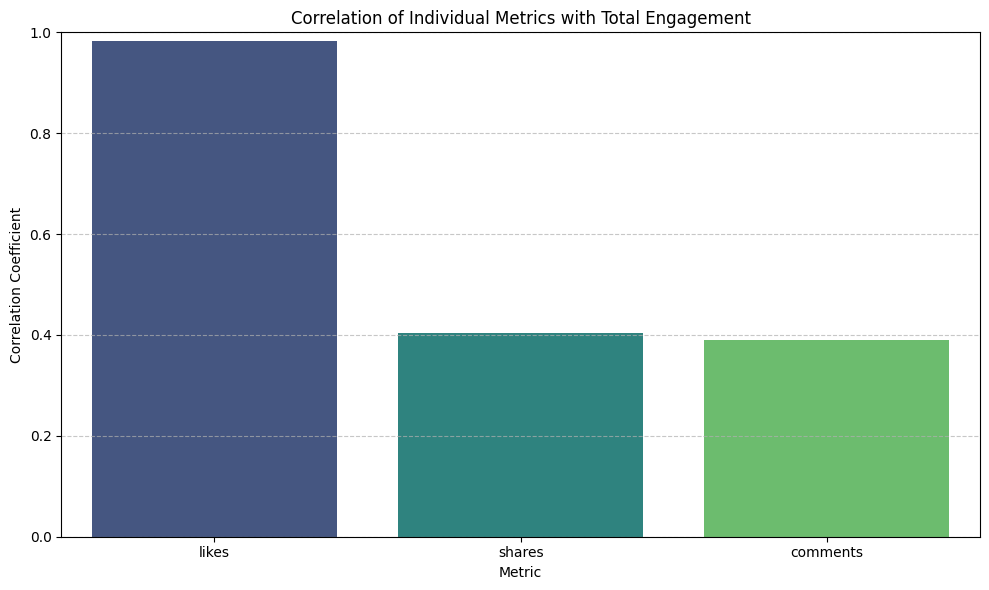

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame from the correlations dictionary
correlations_df = pd.DataFrame(list(correlations.items()), columns=['Metric', 'Correlation with Total Engagement'])

# Sort for better visualization
correlations_df = correlations_df.sort_values(by='Correlation with Total Engagement', ascending=False)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Correlation with Total Engagement', data=correlations_df, palette='viridis', hue='Metric', legend=False)
plt.title('Correlation of Individual Metrics with Total Engagement')
plt.xlabel('Metric')
plt.ylabel('Correlation Coefficient')
plt.ylim(0, 1) # Correlation values range from -1 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Based on these correlations, Likes are the strongest predictor of overall engagement success, with a very high correlation of 0.98. This makes sense, as 'likes' often constitute a large portion of 'total engagement'. Comments and shares also contribute positively but to a lesser extent, with correlations of 0.39 and 0.40, respectively.

# **Advanced/Exploratory**

# Task
## Calculate Average Engagement for Positive Sentiment Posts by Platform

Group the DataFrame by 'platform' and filter for 'positive' sentiment posts, then calculate the mean 'total_engagement'.

## Calculate Average Engagement for Positive Sentiment Posts by Platform

### Subtask:
Calculate the average total engagement for posts with a 'positive' sentiment score, grouped by 'platform'.


**Reasoning**:
I need to filter the DataFrame for posts with a 'positive' sentiment score, then group the filtered data by 'platform' and calculate the average 'total_engagement' for each platform.



In [ ]:
# 1. Filter the DataFrame for posts with 'positive' sentiment score
positive_sentiment_df = df[df['sentiment_score'] == 'positive']

# 2. Group by 'platform' and calculate the mean of 'total_engagement'
positive_sentiment_engagement = positive_sentiment_df.groupby('platform')['total_engagement'].mean().sort_values(ascending=False)

# 3. Print the result
print("Average Engagement for Positive Sentiment Posts by Platform:")
print(positive_sentiment_engagement)

Average Engagement for Positive Sentiment Posts by Platform:
platform
Instagram    4291.571429
Facebook     3186.000000
Twitter      2025.650000
Name: total_engagement, dtype: float64


## Calculate Average Engagement for Negative Sentiment Posts by Platform

### Subtask:
Calculate the average total engagement for posts with a 'negative' sentiment score, grouped by 'platform'.


**Reasoning**:
To calculate the average total engagement for posts with a 'negative' sentiment score, grouped by 'platform', I will first filter the DataFrame to include only posts with 'negative' sentiment. Then, I will group this filtered data by 'platform' and compute the mean of 'total_engagement' for each group. Finally, the results will be printed, sorted in descending order.



In [ ]:
# 1. Filter the DataFrame for posts with 'negative' sentiment score
negative_sentiment_df = df[df['sentiment_score'] == 'negative']

# 2. Group by 'platform' and calculate the mean of 'total_engagement'
negative_sentiment_engagement = negative_sentiment_df.groupby('platform')['total_engagement'].mean().sort_values(ascending=False)

# 3. Print the result
print("Average Engagement for Negative Sentiment Posts by Platform:")
print(negative_sentiment_engagement)

Average Engagement for Negative Sentiment Posts by Platform:
platform
Instagram    3869.500000
Facebook     3635.181818
Twitter      1501.000000
Name: total_engagement, dtype: float64


## Combine and Compare Results

### Subtask:
Merge or combine the average engagement results for positive and negative sentiment posts into a single DataFrame for easier comparison across platforms.


**Reasoning**:
To combine the average engagement results for positive and negative sentiment posts, I need to convert the existing Series into DataFrames, rename their engagement columns for clarity, and then merge them based on the 'platform' column.



In [ ]:
# 1. Convert Series to DataFrame and rename columns
positive_sentiment_engagement_df = positive_sentiment_engagement.reset_index()
positive_sentiment_engagement_df.rename(columns={'total_engagement': 'Positive_Engagement'}, inplace=True)

negative_sentiment_engagement_df = negative_sentiment_engagement.reset_index()
negative_sentiment_engagement_df.rename(columns={'total_engagement': 'Negative_Engagement'}, inplace=True)

# 2. Merge these two DataFrames into a single DataFrame on the 'platform' column
combined_sentiment_engagement = pd.merge(
    positive_sentiment_engagement_df,
    negative_sentiment_engagement_df,
    on='platform',
    how='outer'
).fillna(0)

# 3. Display the combined DataFrame
print("Combined Average Engagement by Platform for Positive and Negative Sentiments:")
print(combined_sentiment_engagement)

Combined Average Engagement by Platform for Positive and Negative Sentiments:
    platform  Positive_Engagement  Negative_Engagement
0   Facebook          3186.000000          3635.181818
1  Instagram          4291.571429          3869.500000
2    Twitter          2025.650000          1501.000000


## Visualize Engagement Efficiency by Sentiment and Platform

### Subtask:
Create a grouped bar chart to visually compare the average total engagement for positive versus negative sentiment posts on each platform.


**Reasoning**:
To visually compare the average total engagement for positive and negative sentiment posts across platforms, I will generate a grouped bar chart using the `combined_sentiment_engagement` DataFrame. First, I need to import the necessary plotting libraries. Then, I will melt the DataFrame to a long format suitable for Seaborn's `barplot` function, and finally, I will create and display the plot with appropriate labels and title.



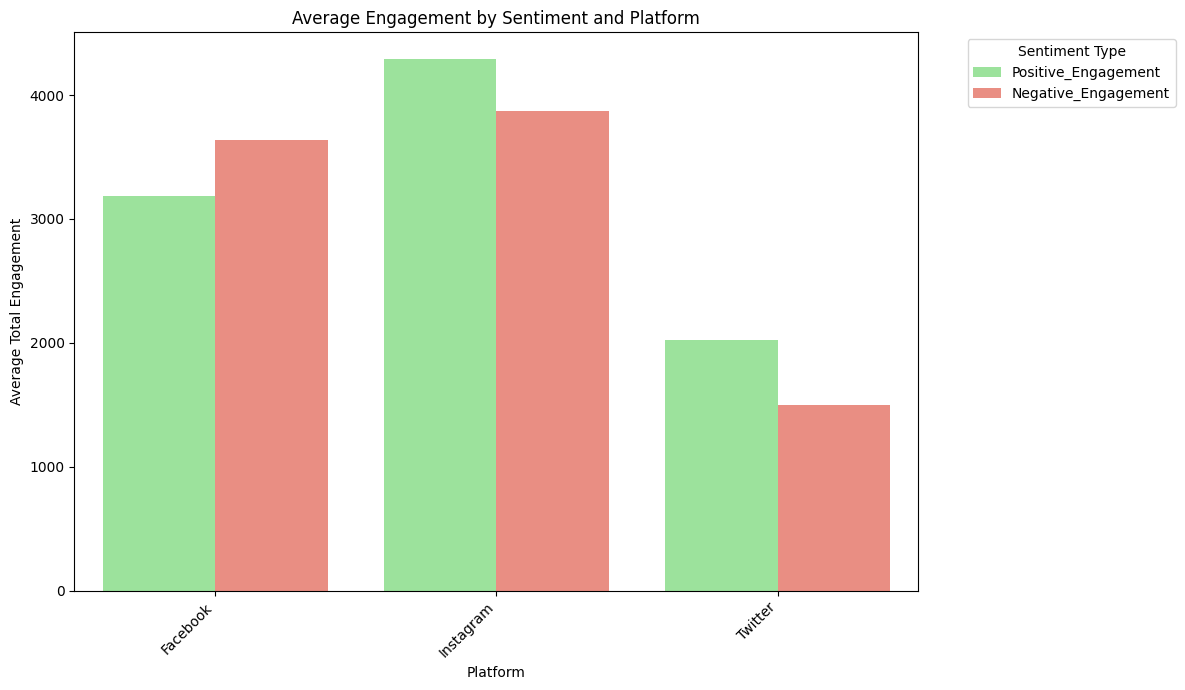

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
sentiment_engagement_melted = combined_sentiment_engagement.melt(
    id_vars='platform',
    var_name='Sentiment Type',
    value_name='Average Engagement'
)

# Create a grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    data=sentiment_engagement_melted,
    x='platform',
    y='Average Engagement',
    hue='Sentiment Type',
    palette={'Positive_Engagement': 'lightgreen', 'Negative_Engagement': 'salmon'}
)
plt.title('Average Engagement by Sentiment and Platform')
plt.xlabel('Platform')
plt.ylabel('Average Total Engagement')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Interpret Findings

### Subtask:
Analyze the visual and numerical results to describe the differences in engagement efficiency between positive and negative sentiment posts across platforms.


## Summary:

### Data Analysis Key Findings

*   **Average Engagement for Positive Sentiment Posts:**
    *   Instagram: 4291.57
    *   Facebook: 3186.00
    *   Twitter: 2025.65
*   **Average Engagement for Negative Sentiment Posts:**
    *   Instagram: 3869.50
    *   Facebook: 3635.18
    *   Twitter: 1501.00
*   **Comparison of Engagement Efficiency by Platform:**
    *   **Instagram** shows the highest average engagement for both positive (4291.57) and negative (3869.50) sentiment posts, suggesting strong overall engagement on this platform regardless of sentiment. Positive posts slightly outperform negative posts.
    *   **Facebook** experiences higher average engagement for negative sentiment posts (3635.18) compared to positive sentiment posts (3186.00), indicating that negative content might be more engaging or elicit more reactions on this platform.
    *   **Twitter** consistently has the lowest average engagement for both positive (2025.65) and negative (1501.00) sentiment posts among the three platforms. Similar to Instagram, positive posts on Twitter tend to have higher engagement than negative ones.

### Insights or Next Steps

*   The effectiveness of sentiment in driving engagement varies significantly by platform. Content strategies should be tailored to each platform, leveraging insights like Facebook's higher negative sentiment engagement or Instagram's strong overall performance.
*   Further investigation could explore the types of content associated with positive versus negative sentiments on Facebook, and what specific characteristics of these posts lead to higher engagement.
